<a href="https://colab.research.google.com/github/Heorhiipro/python-analytics-homework/blob/main/dz_8_6550ee2941a34749923952.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('my_phone.csv')


In [ ]:
#Поглянемо на табличку та подивимося формат даних стовбчиків у таблиці
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4020 entries, 0 to 4019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4020 non-null   int64  
 1   battery_power  4020 non-null   int64  
 2   bluetooth      4020 non-null   object 
 3   weight         4020 non-null   int64  
 4   memory         4020 non-null   int64  
 5   n_cores        4020 non-null   float64
 6   ram            4020 non-null   int64  
 7   dual_sim       4020 non-null   object 
 8   wifi           4020 non-null   int64  
 9   pixel_height   4020 non-null   int64  
 10  pixel_width    4020 non-null   int64  
 11  price_range    3020 non-null   float64
dtypes: float64(2), int64(8), object(2)
memory usage: 377.0+ KB


In [ ]:
df.n_cores.unique().tolist()
#Розуміємо, що кількість ядер не може бути значенням з плаваючею точкою



[2.0, 3.0, 5.0, 6.0, 1.0, 8.0, 4.0, 7.0, 3.5]

In [ ]:
#Тому убираємо значення 3,5 та міняємо формат даних стовбчика на цілий числовий
df = df.loc[df['n_cores'] != 3.5]
df = df.astype({"n_cores": "Int64"})

In [ ]:
#Заміняємо дані в bluetooth та уніфікуємо формат
df['bluetooth'] = df['bluetooth'].replace('YES', 1)
df['bluetooth'] = df['bluetooth'].replace('NO',0)



In [ ]:
#Робимо аналіз на унікальні значення dual_sim
df.dual_sim.unique().tolist()
df.loc[df['dual_sim']=='NO'].value_counts().sum()


44

In [ ]:
#Заміняємо значення 'NO' на 1
df['dual_sim'] = df['dual_sim'].replace('NO', '0')


In [ ]:
#Заміняємо дані в dual_sim та уніфікуємо формат

df = df.astype({"dual_sim": "Int64"})


In [ ]:
#Заміняємо дані в price_range та уніфікуємо формат, проте залишаємо пусті значення
df['price_range'] = np.floor(pd.to_numeric(df['price_range'], errors='coerce')).astype('Int64')

In [ ]:
df['price_range'].unique()

<IntegerArray>
[1, 2, 3, 0, <NA>]
Length: 5, dtype: Int64

In [ ]:
df.describe()

,Unnamed: 0,battery_power,bluetooth,weight,memory,n_cores,ram,dual_sim,wifi,pixel_height,pixel_width,price_range
count,4012.000000,4012.000000,4012.000000,4012.000000,4012.000000,4012.0,4012.000000,4012.0,4012.000000,4012.000000,4012.000000,3012.0
mean,2013.330758,1127.452891,0.374875,139.393071,27.352941,3.964855,1715.258973,0.507228,0.502742,672.384596,1115.869890,1.330677
std,1158.596373,425.980529,0.484151,33.667731,18.095830,2.222258,1184.456373,0.50001,0.500055,404.145129,459.730789,0.939315
min,0.000000,500.000000,0.000000,80.000000,2.000000,1.0,6.000000,0.0,0.000000,0.000000,240.000000,0.0
25%,1010.750000,780.000000,0.000000,111.000000,12.000000,2.0,652.000000,0.0,0.000000,364.750000,739.000000,1.0
50%,2013.500000,983.000000,0.000000,139.000000,22.000000,4.0,1487.500000,1.0,1.000000,634.000000,1064.000000,1.0
75%,3016.250000,1489.000000,1.000000,168.000000,43.000000,6.0,2743.750000,1.0,1.000000,949.250000,1492.250000,2.0
max,4019.000000,1999.000000,1.000000,200.000000,64.000000,8.0,3998.000000,1.0,1.000000,1960.000000,1998.000000,3.0


In [ ]:
#Видаляємо 'pixel_height' значення нижче 0
df=df.loc[df['pixel_height']>0]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4008 entries, 0 to 4019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     4008 non-null   int64
 1   battery_power  4008 non-null   int64
 2   bluetooth      4008 non-null   int64
 3   weight         4008 non-null   int64
 4   memory         4008 non-null   int64
 5   n_cores        4008 non-null   Int64
 6   ram            4008 non-null   int64
 7   dual_sim       4008 non-null   Int64
 8   wifi           4008 non-null   int64
 9   pixel_height   4008 non-null   int64
 10  pixel_width    4008 non-null   int64
 11  price_range    3010 non-null   Int64
dtypes: Int64(3), int64(9)
memory usage: 418.8 KB


In [ ]:
#Створюємо таблицю без пустих значеннь для дослідження даних та тренування моделей
df_cor=df
df_cor=df_cor.dropna()
df_cor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3010 entries, 0 to 4019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     3010 non-null   int64
 1   battery_power  3010 non-null   int64
 2   bluetooth      3010 non-null   int64
 3   weight         3010 non-null   int64
 4   memory         3010 non-null   int64
 5   n_cores        3010 non-null   Int64
 6   ram            3010 non-null   int64
 7   dual_sim       3010 non-null   Int64
 8   wifi           3010 non-null   int64
 9   pixel_height   3010 non-null   int64
 10  pixel_width    3010 non-null   int64
 11  price_range    3010 non-null   Int64
dtypes: Int64(3), int64(9)
memory usage: 314.5 KB


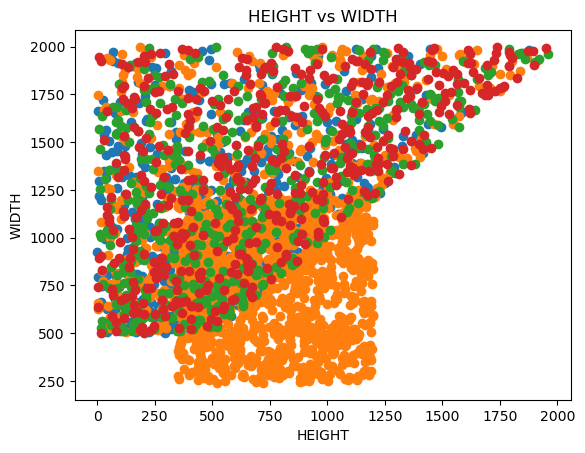

In [ ]:
x1=df_cor[df_cor.price_range==0]['pixel_height']
y1=df_cor[df_cor.price_range==0]['pixel_width']
x2=df_cor[df_cor.price_range==1]['pixel_height']
y2=df_cor[df_cor.price_range==1]['pixel_width']
x3=df_cor[df_cor.price_range==2]['pixel_height']
y3=df_cor[df_cor.price_range==2]['pixel_width']
x4=df_cor[df_cor.price_range==3]['pixel_height']
y4=df_cor[df_cor.price_range==3]['pixel_width']

plt.scatter(x1,y1,label='PR_0')
plt.scatter(x2,y2,label='PR_1')
plt.scatter(x3,y3,label='PR_2')
plt.scatter(x4,y4,label='PR_3')
plt.title('HEIGHT vs WIDTH')
plt.xlabel('HEIGHT')
plt.ylabel('WIDTH')
plt.legend
plt.show()



plt.show()
#На графіку видно, що закономірності зв'язку є, проте розрив даних досить великий, тобто треба звести дані до одного масштабу

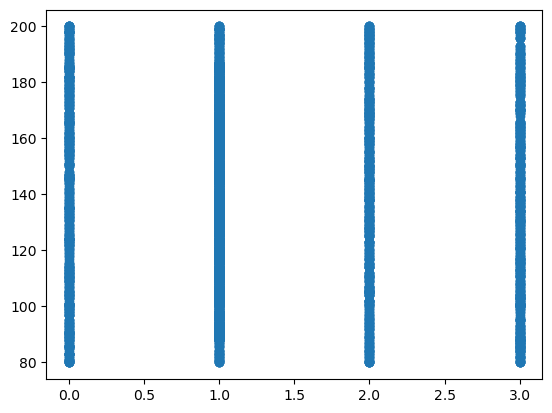

In [ ]:

plt.scatter(df_cor.price_range,df_cor.weight,label='PR_0')

plt.legend
plt.show()



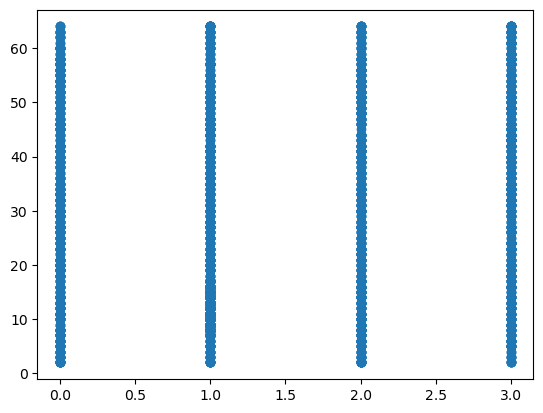

In [ ]:
plt.scatter(df_cor.price_range,df_cor.memory,label='PR_0')


In [ ]:
#Видно на вищевказаних даних всі значення притаманні значенням price range
# тому ці колонки для побудування моделей не знадобляться

In [ ]:
ph=df_cor['pixel_height']
pw=df_cor['pixel_height']
fig, axs = plt.pyplot.subplots(nrows= 2 )
fig. suptitle('Розподілення величин ')
fig. tight_layout (h_pad= 2 )
axs[0].set_title('pixel_height',fontsize= 7.5)
axs[1].set_title('pixel_height',fontsize= 7.5)

axs[0].hist(ph,bins=50,label='sepal_length')
axs[1].hist(pw,bins=50,label='sepal_width')
#Видно що розподіл не є нормальним, тому видаляти 'хвости' не треба,
#адже в великих значеннях можуть зберігатися дані про різні класи прайсів

AttributeError: module 'matplotlib.pyplot' has no attribute 'pyplot'

<Axes: >

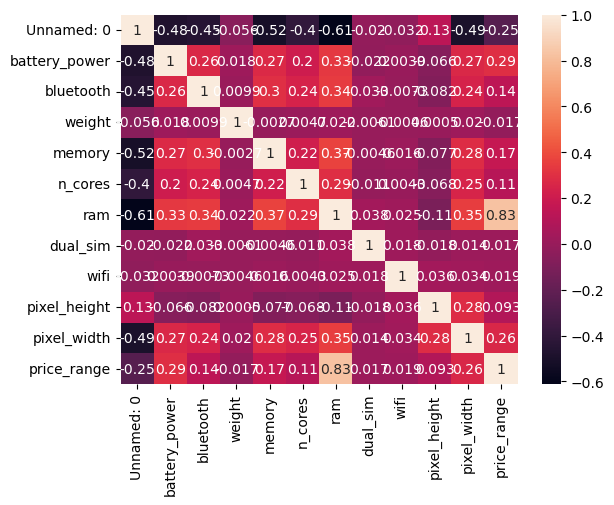

In [ ]:
#Спробуємо знайти кореляцію між значеннями
sns.heatmap(df_cor.corr(),annot=True)
#На графіку видно що добре корелюють між собою тільки price range  та ram

<Axes: xlabel='n_cores'>

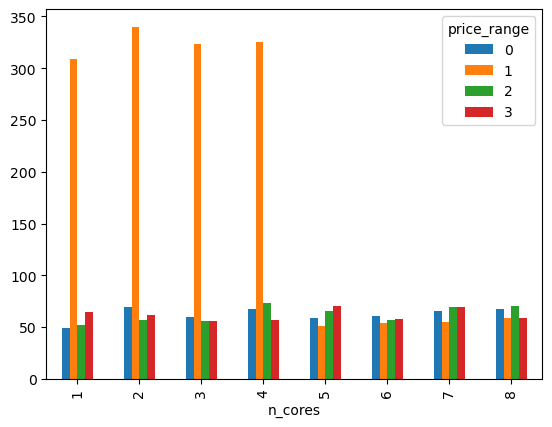

In [ ]:
#Спробуємо знайти напритаманіші риси для кожного price_range
%matplotlib inline


pd.crosstab(df_cor.n_cores,df.price_range).plot(kind='bar')


#На графіку видно, що 1-4 ядра має переважно 1 ранг


<Axes: xlabel='wifi'>

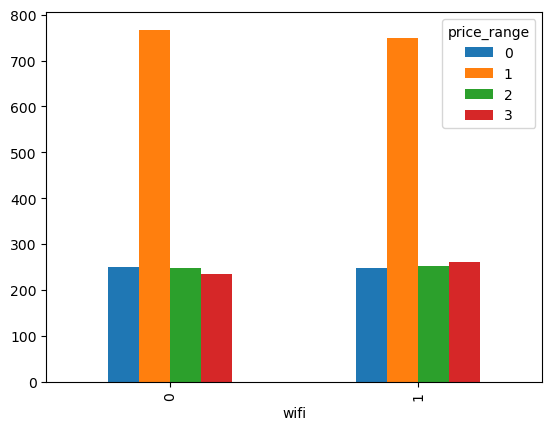

In [ ]:
pd.crosstab(df_cor.wifi,df.price_range).plot(kind='bar')

<Axes: xlabel='bluetooth'>

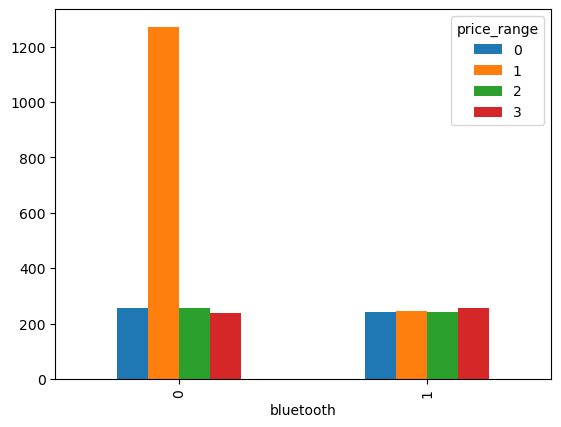

In [ ]:
pd.crosstab(df_cor.bluetooth,df.price_range).plot(kind='bar')

<Axes: xlabel='dual_sim'>

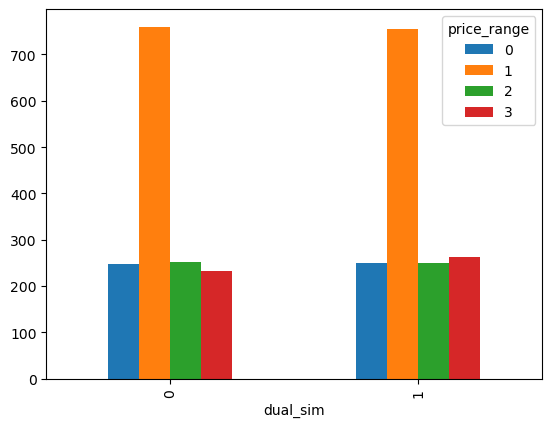

In [ ]:
pd.crosstab(df_cor.dual_sim,df.price_range).plot(kind='bar')

<Axes: >

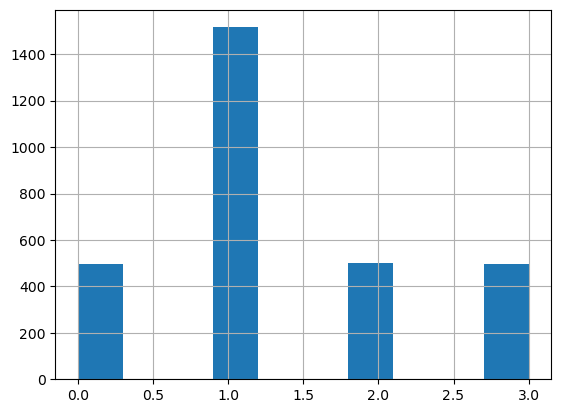

In [ ]:
df.price_range.hist()
#Видно що, кількість даних має досить велику диспропорцію, тож модель може бути неточною
#Також такі колонки як bluetooth, wifi, dual_sim ми при тренуванні регресії використовувати не будем, оскільки сильної кореляції між даними не виявлено
# Також вищевказані колонки будуть нерелевантні дані відображати, оскільки в таблиці занадто велика кількість даних price range 1

In [ ]:
Y=df_cor['price_range']
X=df_cor[['n_cores','ram','pixel_height','pixel_width']]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Створюємо таблицю, до якої будемо аппендити пердікшн моделей
bool_series = pd.isnull(df["price_range"])
df1=df[bool_series]
df1[["price_range"]]

df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 2000 to 2999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     998 non-null    int64
 1   battery_power  998 non-null    int64
 2   bluetooth      998 non-null    int64
 3   weight         998 non-null    int64
 4   memory         998 non-null    int64
 5   n_cores        998 non-null    Int64
 6   ram            998 non-null    int64
 7   dual_sim       998 non-null    Int64
 8   wifi           998 non-null    int64
 9   pixel_height   998 non-null    int64
 10  pixel_width    998 non-null    int64
 11  price_range    0 non-null      Int64
dtypes: Int64(3), int64(9)
memory usage: 104.3 KB


In [ ]:
#Задаємо зміну у таблиці для завдання даних до предікшну
val=df1[['n_cores','ram','pixel_height','pixel_width']]

In [ ]:
val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 2000 to 2999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   n_cores       998 non-null    Int64
 1   ram           998 non-null    int64
 2   pixel_height  998 non-null    int64
 3   pixel_width   998 non-null    int64
dtypes: Int64(1), int64(3)
memory usage: 40.0 KB


In [ ]:
#Будуємо лінійну регресію
from sklearn.linear_model import LinearRegression
linear_regression=LinearRegression()
linear_regression.fit(X_train,Y_train)

LinearRegression()

In [ ]:
Lin_reg_val=linear_regression.predict(X_test)
pred1=Lin_reg_val.round()


In [ ]:
acc = sum(Y_test==pred1)/len(Y_test)*100
print('Accuracy =', acc)

Accuracy = 67.90744466800804


In [ ]:
Lin_reg_val=linear_regression.predict(val)
predLin=Lin_reg_val.round()



In [ ]:
#Додаємо регресію до таблиці з прогнозом
df1['PredLin'] = predLin.tolist()
df1

/tmp/ipykernel_85/1509799001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['PredLin'] = predLin.tolist()


,Unnamed: 0,battery_power,bluetooth,weight,memory,n_cores,ram,dual_sim,wifi,pixel_height,pixel_width,price_range,PredLin
2000,2000,1043,1,193,5,3,3476,1,0,226,1412,<NA>,2.0
2001,2001,841,1,191,61,5,3895,1,0,746,857,<NA>,3.0
2002,2002,1807,1,186,27,3,2396,0,1,1270,1366,<NA>,2.0
2003,2003,1546,0,96,25,8,3893,1,0,295,1752,<NA>,2.0
2004,2004,1434,0,108,49,6,1773,0,1,749,810,<NA>,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1700,1,170,54,7,2121,0,0,644,913,<NA>,2.0
2996,2996,609,0,186,13,4,1933,1,1,1152,1632,<NA>,2.0
2997,2997,1185,0,80,8,1,1223,0,0,477,825,<NA>,1.0
2998,2998,1533,1,171,50,2,2509,1,0,38,832,<NA>,2.0


In [ ]:
#Будуємо логістичну регресію
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 20, solver='lbfgs', multi_class='auto')
classifier.fit(X_train, Y_train)


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=20)

In [ ]:
pred = classifier.predict(X_test)

In [ ]:
probs_y = classifier.predict_proba(X_test)

In [ ]:
probs_y = np.round(probs_y, 2)
probs_y

array([[0.25, 0.71, 0.02, 0.01],
       [0.93, 0.07, 0.  , 0.  ],
       [0.12, 0.75, 0.07, 0.06],
       ...,
       [0.07, 0.45, 0.24, 0.24],
       [0.08, 0.56, 0.19, 0.18],
       [0.13, 0.85, 0.01, 0.01]])

In [ ]:

acc = sum(Y_test==pred)/len(Y_test)*100
print('Accuracy =', acc)

Accuracy = 65.99597585513078


In [ ]:
from sklearn.metrics import accuracy_score
print ("Accuracy : ", accuracy_score(Y_test, pred))


Accuracy :  0.6599597585513078


In [ ]:
predLogReg = classifier.predict(val)
probs_y1 = classifier.predict_proba(val)
probs_y1 = np.round(probs_y1, 2)
probs_y1

array([[0.  , 0.02, 0.35, 0.63],
       [0.  , 0.01, 0.31, 0.68],
       [0.  , 0.38, 0.23, 0.38],
       ...,
       [0.03, 0.36, 0.28, 0.33],
       [0.  , 0.03, 0.38, 0.59],
       [0.  , 0.09, 0.46, 0.45]])

In [ ]:
df1['predLogReg'] = predLogReg.tolist()

/tmp/ipykernel_85/2008728293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['predLogReg'] = predLogReg.tolist()


In [ ]:
df1

,Unnamed: 0,battery_power,bluetooth,weight,memory,n_cores,ram,dual_sim,wifi,pixel_height,pixel_width,price_range,PredLin,predLogReg
2000,2000,1043,1,193,5,3,3476,1,0,226,1412,<NA>,2.0,3.0
2001,2001,841,1,191,61,5,3895,1,0,746,857,<NA>,3.0,3.0
2002,2002,1807,1,186,27,3,2396,0,1,1270,1366,<NA>,2.0,1.0
2003,2003,1546,0,96,25,8,3893,1,0,295,1752,<NA>,2.0,2.0
2004,2004,1434,0,108,49,6,1773,0,1,749,810,<NA>,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1700,1,170,54,7,2121,0,0,644,913,<NA>,2.0,1.0
2996,2996,609,0,186,13,4,1933,1,1,1152,1632,<NA>,2.0,1.0
2997,2997,1185,0,80,8,1,1223,0,0,477,825,<NA>,1.0,1.0
2998,2998,1533,1,171,50,2,2509,1,0,38,832,<NA>,2.0,3.0


In [ ]:
#Будуємо модель кластеризації, кількість сусідніх очок виставляємо методом підбору(емпіричним)
from sklearn import neighbors
KNN_model = neighbors.KNeighborsClassifier(n_neighbors=21)
KNN_model.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=21)

In [ ]:
pred = KNN_model.predict(X_test)
acc = sum(Y_test==pred)/len(Y_test)*100
print('Accuracy =', acc)

Accuracy = 81.08651911468813


In [ ]:
predKNN = KNN_model.predict(val)
predKNN

array([3., 3., 2., 3., 1., 3., 3., 1., 3., 0., 3., 3., 0., 0., 2., 0., 1.,
       1., 3., 1., 1., 3., 1., 2., 3., 0., 2., 0., 3., 0., 2., 1., 3., 1.,
       0., 1., 3., 1., 2., 1., 1., 2., 0., 0., 0., 1., 0., 3., 1., 2., 1.,
       1., 2., 0., 3., 0., 3., 1., 1., 3., 3., 3., 0., 1., 0., 1., 1., 3.,
       1., 2., 1., 1., 2., 3., 3., 1., 2., 0., 2., 3., 0., 3., 3., 0., 3.,
       0., 3., 1., 2., 1., 1., 1., 2., 0., 2., 1., 0., 2., 1., 3., 1., 0.,
       0., 3., 1., 2., 0., 1., 2., 3., 3., 3., 1., 3., 3., 3., 3., 1., 3.,
       0., 1., 3., 2., 1., 1., 0., 3., 2., 3., 1., 0., 1., 1., 1., 3., 1.,
       1., 0., 3., 3., 1., 2., 2., 2., 3., 3., 3., 2., 2., 3., 2., 3., 0.,
       0., 2., 2., 3., 3., 3., 3., 2., 2., 3., 3., 3., 3., 1., 1., 3., 0.,
       0., 1., 2., 0., 1., 2., 0., 0., 1., 2., 0., 0., 0., 1., 2., 3., 2.,
       1., 0., 1., 0., 0., 1., 3., 1., 0., 3., 1., 3., 2., 0., 2., 2., 3.,
       3., 1., 2., 1., 0., 1., 1., 2., 0., 3., 3., 3., 0., 2., 1., 3., 2.,
       2., 3., 0., 0., 1.

In [ ]:
df1['predKNN'] = predKNN.tolist()

/tmp/ipykernel_85/3613702943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['predKNN'] = predKNN.tolist()


In [ ]:
df1

,Unnamed: 0,battery_power,bluetooth,weight,memory,n_cores,ram,dual_sim,wifi,pixel_height,pixel_width,price_range,PredLin,predLogReg,predKNN
2000,2000,1043,1,193,5,3,3476,1,0,226,1412,<NA>,2.0,3.0,3.0
2001,2001,841,1,191,61,5,3895,1,0,746,857,<NA>,3.0,3.0,3.0
2002,2002,1807,1,186,27,3,2396,0,1,1270,1366,<NA>,2.0,1.0,2.0
2003,2003,1546,0,96,25,8,3893,1,0,295,1752,<NA>,2.0,2.0,3.0
2004,2004,1434,0,108,49,6,1773,0,1,749,810,<NA>,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1700,1,170,54,7,2121,0,0,644,913,<NA>,2.0,1.0,1.0
2996,2996,609,0,186,13,4,1933,1,1,1152,1632,<NA>,2.0,1.0,2.0
2997,2997,1185,0,80,8,1,1223,0,0,477,825,<NA>,1.0,1.0,0.0
2998,2998,1533,1,171,50,2,2509,1,0,38,832,<NA>,2.0,3.0,2.0
